# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [277]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los archivos CSV
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

# Mostrar las primeras 5 filas
display(plans.head())
display(users.head())
display(usage.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**
Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  


In [278]:
# revisar el número de filas y columnas de cada dataset
print("Dimensiones de plans:", plans.shape)
print("Dimensiones de users:", users.shape)
print("Dimensiones de usage:", usage.shape)

Dimensiones de plans: (2, 8)
Dimensiones de users: (4000, 8)
Dimensiones de usage: (40000, 6)


In [279]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [280]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [281]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**INSTRUCCIONES**
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [282]:
# CANTIDAD de nulos para users
users.isna().sum()

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

In [283]:
# PROPORCION de nulos para users
users.isna().mean()

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64

In [284]:
# cantidad de nulos para usage
usage.isna().sum()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

In [285]:
# PROPORCION de nulos en usage
usage.isna().mean()

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64

✍️ **Comentario**: Para los dos datasets (usage y users) se pueden evidenciar valores nulos, en el caso de usage estos valores rondan el 50% de su respectiva columna, por lo cual se recomendaria imputar estos valores ya que el dejarlos como nulos nos puede perjuricar a la hora de querer tener datos y resultados coherentes con la realidad.

para el caso de users, en la columna city hay valores faltantes pero este valor es pequeño en proporcion al total de datos, por lo cual no habria problema en dejarlos como nulos, sin embargo, para el caso de la columna Churn Date, la cual tiene cerca del 90% de valores nulos, se debe eliminar.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
R// En el dataset Users, las columnas City y Churn Date contienen valores faltantes, en un 11.7% y 88.3% respectivamente.
Para el caso del dataset Usage, las columnas Date, Duration y Lenght contienen valores faltantes en un 0,1%, 55% y 44,7% respectivamente.
- Indica qué harías: ¿imputar, eliminar, ignorar?
R// Para todas aquellas columnas con valores faltantes que representen un valor mayor al 80%, se pueden eliminar, es un porcentaje demasiado alto como para imputar valores, para las demas columnas con valores faltantes menores al 80%, se pueden imputar o eliminar dependiendo que tan bajo sea el porcentaje, si es menor a 5% se puede ignorar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [286]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [287]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [288]:
# explorar columnas categóricas de users
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [289]:
# explorar columna categórica de usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---
✍️ **Comentario**: En el dataset Users, columna Age, evidenciamos un minimo de -999, valor que podriamos catalogar como sentinel, por lo que podemos reemplazarlo por un Nan, para tener un mejor análisis de los datos.
 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [290]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

In [291]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")

In [292]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [293]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

**Comentario**
Todos los años tienen coherencia con el caso, no hay años imposibles o fuera del rango esperable, para el año 2026 se evidencian pocos registros comparado con los demas años, lo cual es esperable teniendo en cuenta que el año no ha transcurrido en su totalidad.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [294]:
# Reemplazar -999 por la mediana de age
median_age = users.loc[users["age"] != -999, "age"].median()

users["age"] = users["age"].replace(-999, median_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [295]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [296]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [297]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [298]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

In [299]:
# No reemplazar ni eliminar los valores nulos
usage["duration"] = usage["duration"]
usage["length"] = usage["length"]

Ya que los valores de Duration y Lenght dependen directamente de la columna type, el reemplazarlos por valores diferentes puede afectar la interpretación que se hace de los datos, por lo cual se recomienda dejarlos como Nulos para saber que los valores con los que se cuenta, son reales y no afectarán posteriormente al análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [300]:
usage_summary = usage.groupby("user_id").agg(
    cant_mensajes=("type", lambda x: (x == "message").sum()),
    cant_llamadas=("type", lambda x: (x == "call").sum()),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

In [301]:
users = users.merge(usage_summary, on="user_id", how="left")
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,0.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,0.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,0.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,0.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [302]:
# Resumen estadístico de las columnas numéricas
users[[
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.0,3999.000000,3999.000000
mean,48.136000,0.0,4.478120,23.317054
std,17.689919,0.0,2.144238,18.168095
min,18.000000,0.0,0.000000,0.000000
25%,33.000000,0.0,3.000000,11.120000
50%,48.000000,0.0,4.000000,19.780000
75%,63.000000,0.0,6.000000,31.415000
max,79.000000,0.0,15.000000,155.690000


In [303]:
users["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

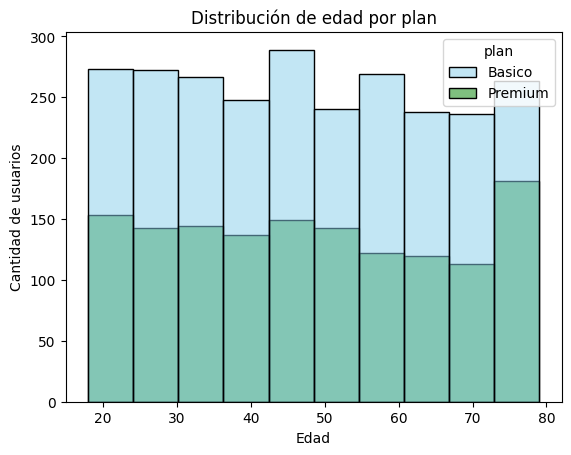

In [304]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=users,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

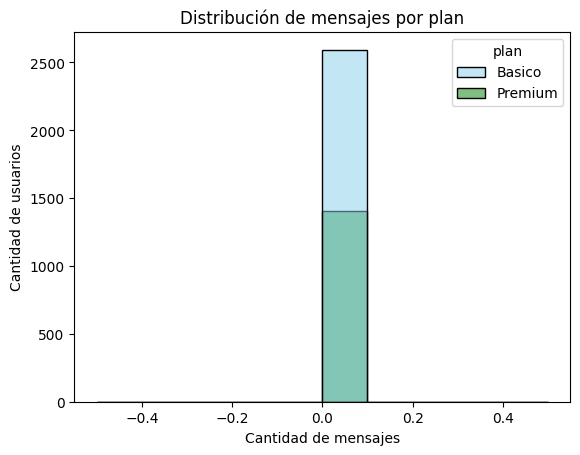

In [305]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=users,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

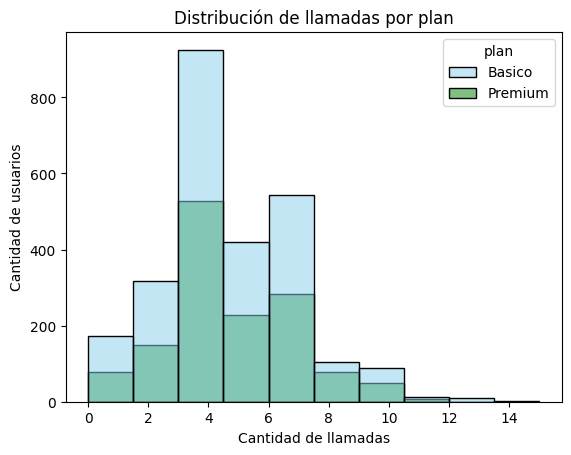

In [306]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=users,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

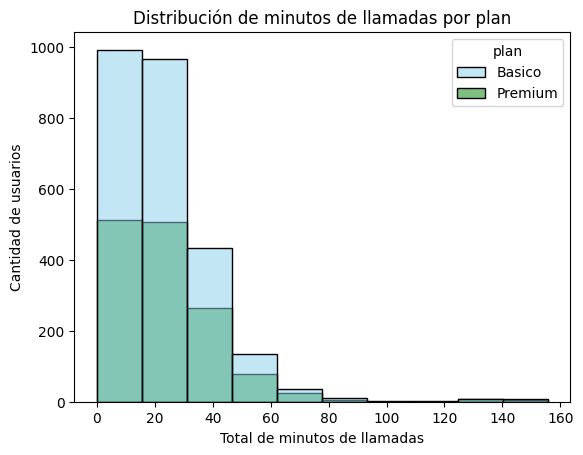

In [307]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=users,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10
)

plt.title("Distribución de minutos de llamadas por plan")
plt.xlabel("Total de minutos de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

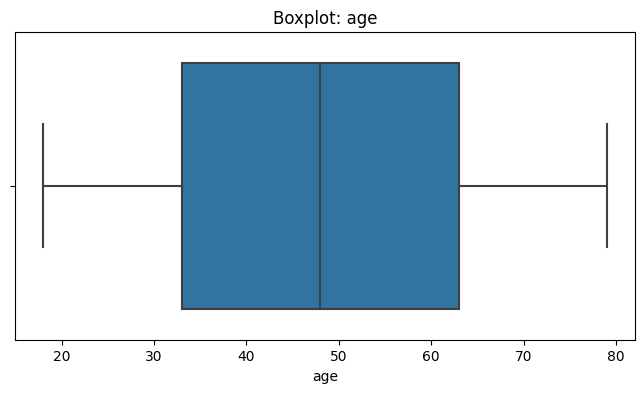

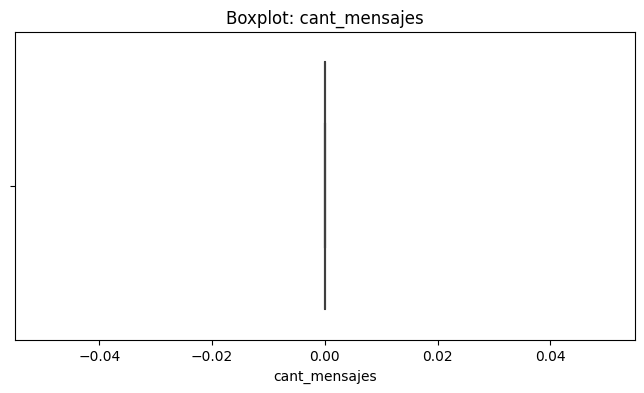

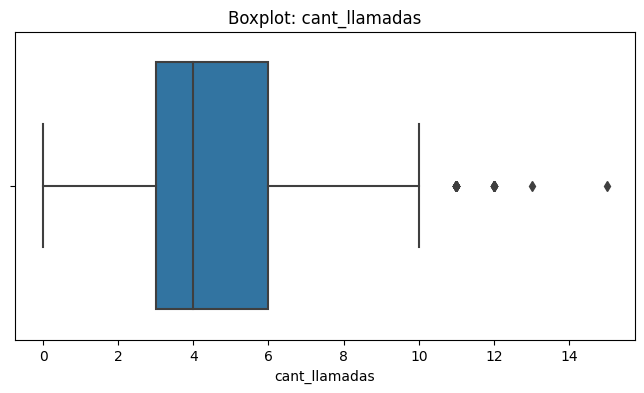

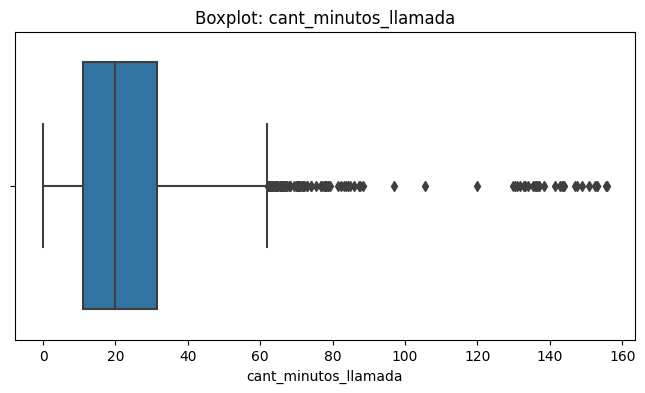

In [308]:
# Visualizando usando BoxPlot 
columnas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=users, x=col)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

In [309]:
# Calcular límites con el método IQR
for col in columnas:
    Q1 = users[col].quantile(0.25)
    Q3 = users[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = users[
        (users[col] < limite_inferior) |
        (users[col] > limite_superior)
    ]

    print(f"\n{col}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")


age
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

cant_mensajes
Límite inferior: 0.00
Límite superior: 0.00
Cantidad de outliers: 0

cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [310]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas:
    Q1 = users[col].quantile(0.25)
    Q3 = users[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    maximo = users[col].max()

    print(f"{col}:")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Máximo: {maximo:.2f}")
    print()

age:
Límite superior: 108.00
Máximo: 79.00

cant_mensajes:
Límite superior: 0.00
Máximo: 0.00

cant_llamadas:
Límite superior: 10.50
Máximo: 15.00

cant_minutos_llamada:
Límite superior: 61.86
Máximo: 155.69



💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
R// No se registran mensajes.
- cant_llamadas/ cant_minutos_llamada: mantener o no outliers, porqué?
R// A pesar de que para estas dos columnas, el valor maximo esta por encima del limite, son valores posibles y esperables de cierta manera, por lo que se deben mantener, esto nos da una mejor visión de la realidad y como esto se ve reflejado en los resultados.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [311]:
user_profile = users.copy()

In [312]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]

valores = [
    "Bajo uso",
    "Uso medio"
]

user_profile["grupo_uso"] = np.select(
    condiciones,
    valores,
    default="Alto uso"
)

In [313]:
# verificar cambios
user_profile["grupo_uso"].value_counts()

Bajo uso     2170
Uso medio    1759
Alto uso       71
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [314]:
# Crear columna grupo_edad
condiciones = [
    user_profile["age"] < 30,
    user_profile["age"] < 60
]

valores = [
    "Joven",
    "Adulto"
]

user_profile["grupo_edad"] = np.select(
    condiciones,
    valores,
    default="Adulto Mayor"
)

In [315]:
user_profile["grupo_edad"].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [316]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,0.0,3.0,23.70,Bajo uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,0.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,0.0,2.0,10.74,Bajo uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,0.0,3.0,8.99,Bajo uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,0.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

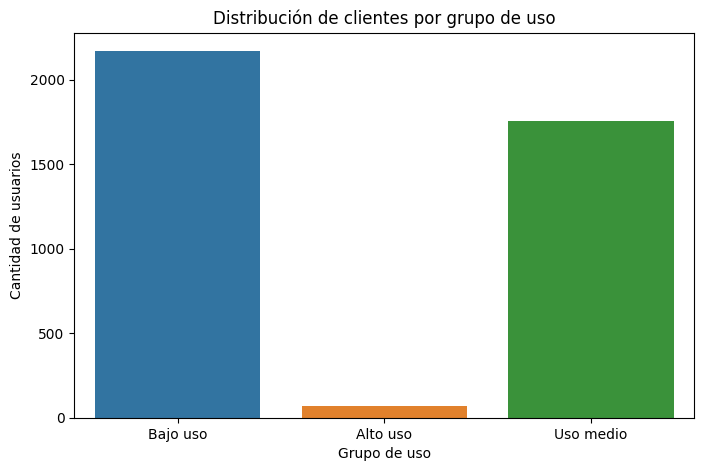

In [317]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x="grupo_uso"
)

plt.title("Distribución de clientes por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

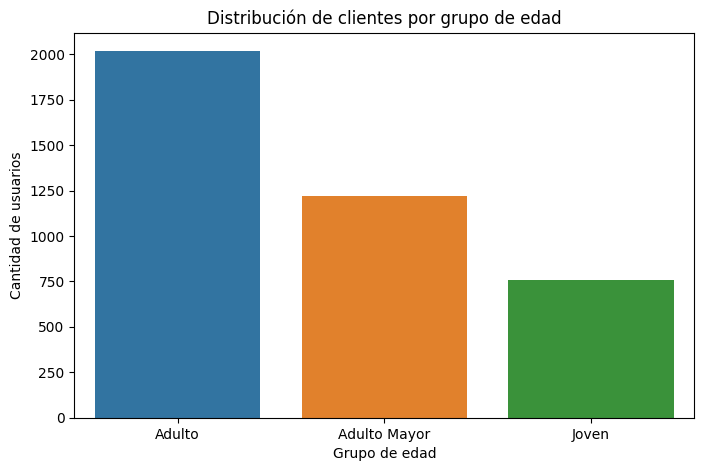

In [318]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x="grupo_edad"
)

plt.title("Distribución de clientes por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
R// Los problemas iniciales que presentaban los datos eran los valores nulos y los sentinels, dado que con estos valores, inicialmente no era posible hacer un analisis real del comportamiento de los usuarios, posterior a la limpieza aplicada, se pudo obtener un mejor panorama de la empresa.
En el dataset Users, las columnas City y Churn Date contienen valores faltantes, en un 11.7% y 88.3% respectivamente. Para el caso del dataset Usage, las columnas Date, Duration y Lenght contienen valores faltantes en un 0,1%, 55% y 44,7% respectivamente.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
R// Los segmentos de cliente se podrian clasificar en dos, segun su edad y segun su tipo de plan, se identifico que los clientes de mayor edad son los que mas tienden a pagar el plan premium, lo cual lleva directamente a la segunda segmentacion posible y es por el tipo de plan al cual pertenece cada cliente, estos dos segmentos le dan a la empresa una idea sencilla de como se pueden comportar sus usuarios dependiendo las campañas implementadas y de como los usuarios hacen uso de sus servicios.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
R// Dado que se identifico que los usuarios de mayor edad tienden en su mayoria a pagar el plan premium, el cual genera un mayor ingreso para la empresa, se deberia identificar el por que los usuarios dentro de este rango de edad optan por este plan y fortalecer todas aquellas estrategias que fomentan esta decision.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
la mayoria de las llamadas tienen una duracion promedio de 20 minutos, sin embargo, un pequeño porcentaje de las mismas tiene duraciones superiores a los 150 minutos, esto puede ser de gran importancia para el negocio pues si se identifica el rango de edad o el plan al que pertenecen estos usuarios se pueden desarrollar estrategias de negocio y marketing para que mas usuarios tengan tiempos de llamada promedio mas largos, en caso de que estas se usen para negocios, conferencias o motivos familiares.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
se pueden implementar dos nuevos planes, uno que se encuentre en medio del plan basico y el plan premium, que con un precio atractivo, ofrezca ciertas caracteristicas premium para aquellos usuarios que esten dispuestos a pagar un poco mas por ciertas caracteristicas. Adicional a esto, se puede crear un plan exclusivo para empresas o negocios, que con un costo un poco mayor al premium habitual, ofrezca caracteristicas atractivas para todos aquellos usuarios que suelan registrar llamadas con duraciones mucho myores al promedio o que usen las llamadas para eventos muy puntuales relacionados con sus empresas.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Outliers
- Valores Faltantes

🔍 **Segmentos por Edad**
- Adulto Mayor
- Adulto
- Joven

📊 **Segmentos por Nivel de Uso**
- Bajo uso
- Alto uso
- Uso medio

💡 **Recomendaciones**
- En cualquier dataset es totalmente normal y esperable que existan datos faltantes o no coherentes con la realidad, lo realmente importante es la proporcion de estos datos con respecto a la totalidad del dataset, pues es a partir de este porcentaje que se puede determinar el plan de acción y tratamiento que se le va a dar a estos datos. si es un porcentaje muy alto, dificilmente se va a poder tener en consideración dicha variable, por el contrario, si el porcentaje es bajo, resulta más facil como analista, reemplazar o eliminar ese dato, pues no va a afectar en mayor medida al analisis global.
- En cuanto a la segmentacion por edad, con la comparacion del tipo de plan por edad, se podria establecer una nueva segmentación de los tipos de plan que ofrece la empresa, esto con el fin de ajustarse mejor a los diferentes publicos objetivo que se pueden tener teniendo en cuenta la edad, necesidades y capacidad adquisitiva de cada segmento en funcion de su edad, es esperable que los mas jovenes en su mayoria no puedan destinar un valor muy alto al plan de telefonia, mientras que a mayor edad, lo esperable es que se pueda contar con mayor capacidad adquisitiva para invertir en este tipo de planes, mas aun si se usan con fines comerciales o empresariales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`